# SNR Requirements and HWO Mission Design

1. At what SNR can each atmospheric species be detected at $\geq 3\sigma$?
2. How do retrieval uncertainties scale with SNR, and which parameters are SNR-limited vs. model-limited?
3. Which parameter pairs are degenerate (correlated epistemic uncertainty), and can higher SNR break these degeneracies?
4. How do detection thresholds change with target distance and host stellar type?
5. Where does the HWO (nominal aperture $D \approx 6$ m) fall between HabEx ($D = 4$ m) and LUVOIR-B ($D = 8$ m)?


# Setup

In [1]:
import os
import json

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
from scipy.stats import mannwhitneyu
import tensorflow as tf
from tqdm import tqdm

from geexhp import datavis

datavis.configure_matplotlib()
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

2026-04-09 07:01:47.629782: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 07:01:47.649246: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-09 07:01:47.759854: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-09 07:01:47.874193: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775728907.983582   97867 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775728908.01

**Telescope parameters**:

| Instrument | Aperture | Bands | Spectral bins | Prefix in TFRecord |
|------------|----------|-------|---------------|--------------------|
| LUVOIR-B | 8 m | UV + Vis + NIR | 8 + 94 + 49 = **151** | `B-{UV,Vis,NIR}` |
| HabEx/SS | 4 m | UV + Vis + NIR | 7 + 109 + 25 = **141** | `SS-{UV,Vis,NIR}` |
| HWO (nominal) | 6 m | — | — | *interpolated* |

**SNR scale factors** `SNR_SCALES = [0.5, 1.0, 2.0, 4.0]` were used in Notebook 13 to bootstrap noise at four intensity levels. The multiplier $s$ acts directly on the photon-noise amplitude stored in each TFRecord, simulating observations that are 2x closer ($s=0.5$) or 4x farther ($s=4$) than the reference distance.

In [2]:
SNR_SCALES = [0.5, 1.0, 2.0, 4.0]

TELESCOPE_CONFIG = {
    "LUVOIR": {
        "prefix": "B",
        "bins": {"UV": 8, "Vis": 94, "NIR": 49},
        "aperture_m": 8.0,
    },
    "HABEX": {
        "prefix": "SS",
        "bins": {"UV": 7, "Vis": 109, "NIR": 25},
        "aperture_m": 4.0,
    },
}
HWO_APERTURE_M = 6.0

PHYS_PARAMS = [
    "OBJECT-RADIUS-REL-EARTH",
    "OBJECT-GRAVITY",
    "ATMOSPHERE-TEMPERATURE",
    "ATMOSPHERE-PRESSURE",
]
MAIN_CHEM = ["O2", "O3"]
OTHER_CHEM = ["CH4", "CO2", "H2O", "N2"]
ALL_PARAMS = PHYS_PARAMS + MAIN_CHEM + OTHER_CHEM

PARAM_LABELS = [
    r"R$_\oplus$",
    r"$g$",
    r"$T_{\rm surf}$",
    r"$P_{\rm surf}$",
    r"O$_2$",
    r"O$_3$",
    r"CH$_4$",
    r"CO$_2$",
    r"H$_2$O",
    r"N$_2$",
]
N_PARAMS = len(PARAM_LABELS)

CHEM_IDX = {"O2": 4, "O3": 5, "CH4": 6, "CO2": 7, "H2O": 8, "N2": 9}
CHEM_LABEL = {
    "O2": r"O$_2$",
    "O3": r"O$_3$",
    "CH4": r"CH$_4$",
    "CO2": r"CO$_2$",
    "H2O": r"H$_2$O",
    "N2": r"N$_2$",
}

ERA_ORDER = ["modern", "proterozoic", "archean"]
ERA_COLORS = {"modern": "tab:blue", "proterozoic": "tab:green", "archean": "tab:orange"}

TEL_COLORS = {"LUVOIR": "#223648", "HABEX": "#b2182b", "HWO": "#4dac26"}

CMAP10 = mpl.colormaps["tab10"]
PARAM_COLORS = [CMAP10(i) for i in range(N_PARAMS)]

DETECTION_SIGMA = 3.0

In [3]:
with open("../data/normalization_stats.json") as f:
    norm_stats = json.load(f)


def norm_physical(x_phys, name):
    """Physical value model output space (min-max, then power transform)"""
    pmin = norm_stats["outputs"][name]["min"]
    pmax = norm_stats["outputs"][name]["max"]
    n = norm_stats["outputs"][name]["best_n"]
    z = (np.asarray(x_phys, float) - pmin) / (pmax - pmin)
    return np.clip(z, 0.0, 1.0) ** (1.0 / n)


def norm_chem(x_phys, name):
    """Chemical mixing ratio model output space via power transform"""
    n = norm_stats["outputs"][name]["best_n"]
    return np.asarray(x_phys, float) ** (1.0 / n)


def get_std_matrix(result):
    """Concatenate per-head std arrays"""
    return np.concatenate(
        [
            result["physical"]["std"],
            result["main_chem"]["std"],
            result["other_chem"]["std"],
        ],
        axis=1,
    )


def get_mean_matrix(result):
    """Concatenate per-head mean arrays"""
    return np.concatenate(
        [
            result["physical"]["mean"],
            result["main_chem"]["mean"],
            result["other_chem"]["mean"],
        ],
        axis=1,
    )

# Test Dataset

In [4]:
feature_desc = {
    "OBJECT-STAR-TYPE": tf.io.FixedLenFeature([], tf.string),
    "GEOMETRY-OBS-ALTITUDE": tf.io.FixedLenFeature([], tf.float32),
    "Earth_type": tf.io.FixedLenFeature([], tf.string),
    "OBJECT-RADIUS-REL-EARTH": tf.io.FixedLenFeature([], tf.float32),
    "OBJECT-GRAVITY": tf.io.FixedLenFeature([], tf.float32),
    "ATMOSPHERE-TEMPERATURE": tf.io.FixedLenFeature([], tf.float32),
    "ATMOSPHERE-PRESSURE": tf.io.FixedLenFeature([], tf.float32),
    "CH4": tf.io.FixedLenFeature([], tf.float32),
    "CO2": tf.io.FixedLenFeature([], tf.float32),
    "H2O": tf.io.FixedLenFeature([], tf.float32),
    "N2": tf.io.FixedLenFeature([], tf.float32),
    "O2": tf.io.FixedLenFeature([], tf.float32),
    "O3": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_B-Vis": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_SS-Vis": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_B-UV": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_B-NIR": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_SS-UV": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_SS-NIR": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_B-Vis": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_SS-Vis": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_B-UV": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_B-NIR": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_SS-UV": tf.io.FixedLenFeature([], tf.float32),
    "SNR_FEATURE_PCTL_SS-NIR": tf.io.FixedLenFeature([], tf.float32),
}

records = {k: [] for k in feature_desc}
for raw_rec in tqdm(
    tf.data.TFRecordDataset("../data/test.tfrecord"), desc="Loading TFRecord"
):
    parsed = tf.io.parse_single_example(raw_rec, feature_desc)
    for k in feature_desc:
        val = parsed[k].numpy()
        records[k].append(val.decode() if isinstance(val, bytes) else float(val))

meta_df = pd.DataFrame(records).rename(
    columns={
        "OBJECT-STAR-TYPE": "star_type",
        "GEOMETRY-OBS-ALTITUDE": "distance_pc",
        "Earth_type": "era",
    }
)
N = len(meta_df)
print(f"Loaded {N} samples")
print(meta_df[["star_type", "era"]].value_counts().sort_index())
print(
    f"\nDistance range: {meta_df.distance_pc.min():.1f} - {meta_df.distance_pc.max():.1f} pc  "
    f"(median {meta_df.distance_pc.median():.1f} pc)"
)
print(
    f"Median SNR_FEATURE_B-Vis  (amplitude): {meta_df['SNR_FEATURE_B-Vis'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_PCTL_B-Vis (percentile): {meta_df['SNR_FEATURE_PCTL_B-Vis'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_SS-Vis (amplitude): {meta_df['SNR_FEATURE_SS-Vis'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_PCTL_SS-Vis (percentile): {meta_df['SNR_FEATURE_PCTL_SS-Vis'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_B-UV  (amplitude): {meta_df['SNR_FEATURE_B-UV'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_PCTL_B-UV (percentile): {meta_df['SNR_FEATURE_PCTL_B-UV'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_SS-UV (amplitude): {meta_df['SNR_FEATURE_SS-UV'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_PCTL_SS-UV (percentile): {meta_df['SNR_FEATURE_PCTL_SS-UV'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_B-NIR  (amplitude): {meta_df['SNR_FEATURE_B-NIR'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_PCTL_B-NIR (percentile): {meta_df['SNR_FEATURE_PCTL_B-NIR'].median():.1f}"
)
print(
    f"Median SNR_FEATURE_SS-NIR (amplitude): {meta_df['SNR_FEATURE_SS-NIR'].median():.1f}"
)

2026-04-09 07:02:00.878966: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
Loading TFRecord: 0it [00:00, ?it/s]

2026-04-09 07:02:01.067961: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
Loading TFRecord: 10825it [00:17, 755.89it/s]2026-04-09 07:02:19.009950: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Loading TFRecord: 10826it [00:17, 601.56it/s]

Loaded 10826 samples
star_type  era        
F          archean        2780
           modern         2937
           proterozoic    3379
G          archean         632
           modern          601
           proterozoic     497
Name: count, dtype: int64

Distance range: 5.0 - 16.2 pc  (median 6.8 pc)
Median SNR_FEATURE_B-Vis  (amplitude): 27.3
Median SNR_FEATURE_PCTL_B-Vis (percentile): 15.0
Median SNR_FEATURE_SS-Vis (amplitude): 16.0
Median SNR_FEATURE_PCTL_SS-Vis (percentile): 8.6
Median SNR_FEATURE_B-UV  (amplitude): 46.0
Median SNR_FEATURE_PCTL_B-UV (percentile): 25.6
Median SNR_FEATURE_SS-UV (amplitude): 57.6
Median SNR_FEATURE_PCTL_SS-UV (percentile): 44.0
Median SNR_FEATURE_B-NIR  (amplitude): 11.8
Median SNR_FEATURE_PCTL_B-NIR (percentile): 7.7
Median SNR_FEATURE_SS-NIR (amplitude): 15.4


# Data loading

In [5]:
cu = np.load("../data/bootstrap/combined_uncertainty.npy", allow_pickle=True).item()

sigma_model = {
    "LUVOIR": cu["luvoir"]["sigma_model"],  # (N, 10)
    "HABEX": cu["habex"]["sigma_model"],
}
sigma_data_1x = {
    "LUVOIR": cu["luvoir"]["sigma_data"],
    "HABEX": cu["habex"]["sigma_data"],
}
sigma_total_1x = {
    "LUVOIR": cu["luvoir"]["sigma_total"],
    "HABEX": cu["habex"]["sigma_total"],
}

bootstrap = {}
for tel in ["LUVOIR", "HABEX"]:
    bootstrap[tel] = {}
    for s in SNR_SCALES:
        fname = f"../data/bootstrap/bootstrap_{tel.lower()}_{s}x.npy"
        bootstrap[tel][s] = np.load(fname, allow_pickle=True).item()

std_data = {
    tel: {s: get_std_matrix(bootstrap[tel][s]) for s in SNR_SCALES}
    for tel in ["LUVOIR", "HABEX"]
}

z_true = np.column_stack(
    [
        norm_physical(meta_df["OBJECT-RADIUS-REL-EARTH"], "OBJECT-RADIUS-REL-EARTH"),
        norm_physical(meta_df["OBJECT-GRAVITY"], "OBJECT-GRAVITY"),
        norm_physical(meta_df["ATMOSPHERE-TEMPERATURE"], "ATMOSPHERE-TEMPERATURE"),
        norm_physical(meta_df["ATMOSPHERE-PRESSURE"], "ATMOSPHERE-PRESSURE"),
        norm_chem(meta_df["O2"], "O2"),
        norm_chem(meta_df["O3"], "O3"),
        norm_chem(meta_df["CH4"], "CH4"),
        norm_chem(meta_df["CO2"], "CO2"),
        norm_chem(meta_df["H2O"], "H2O"),
        norm_chem(meta_df["N2"], "N2"),
    ]
)

print("z_true shape:", z_true.shape)
pd.DataFrame({"param": PARAM_LABELS, "median_z": np.median(z_true, axis=0)}).set_index(
    "param"
)

z_true shape: (10826, 10)


,median_z
param,
R$_\oplus$,0.738188
$g$,0.681734
$T_{\rm surf}$,0.190307
$P_{\rm surf}$,0.576137
O$_2$,0.080820
O$_3$,0.284977
CH$_4$,0.343291
CO$_2$,0.241386
H$_2$O,0.288018


# Effective SNR Distribution

Two scalar SNR metrics are stored per spectral band in the TFRecord:

**Amplitude-based** (`SNR_FEATURE`):
$$
S_{\rm amp} = \frac{A_{\max} - A_{\min}}{\sqrt{N_{\max}^2 + N_{\min}^2}}
$$ 

**Percentile-based** (`SNR_FEATURE_PCTL`):
$$
S_{\rm PCTL} = \frac{A_{P_{90}} - A_{P_{10}}}{\sqrt{2}\,\sigma_{\rm RMS}}
$$

For a photon-noise-limited observation at fixed integration time and aperture, the signal photon count scales as $N_{\rm phot} \propto F_\star / d^2$, giving 
$$
\text{SNR} = \sqrt{N_{\rm phot}} \propto \frac{1}{d}
$$
We therefore expect $S_{\rm PCTL}(d) \propto 1/d$ at fixed telescope and planet parameters.

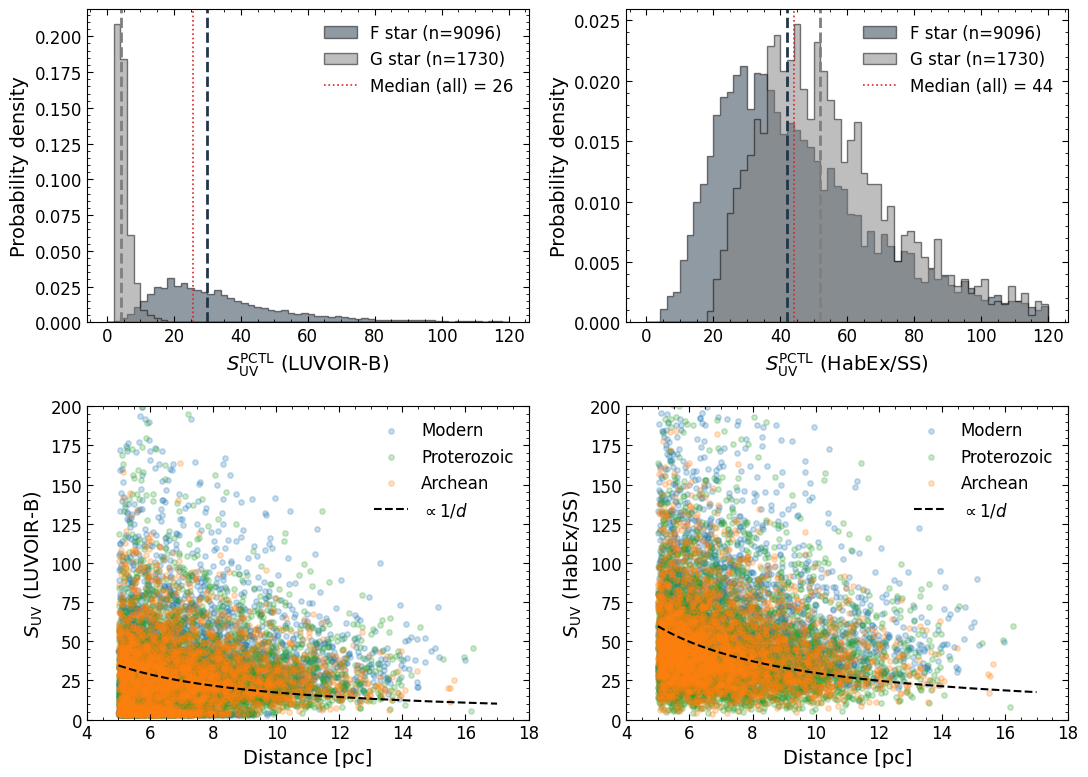

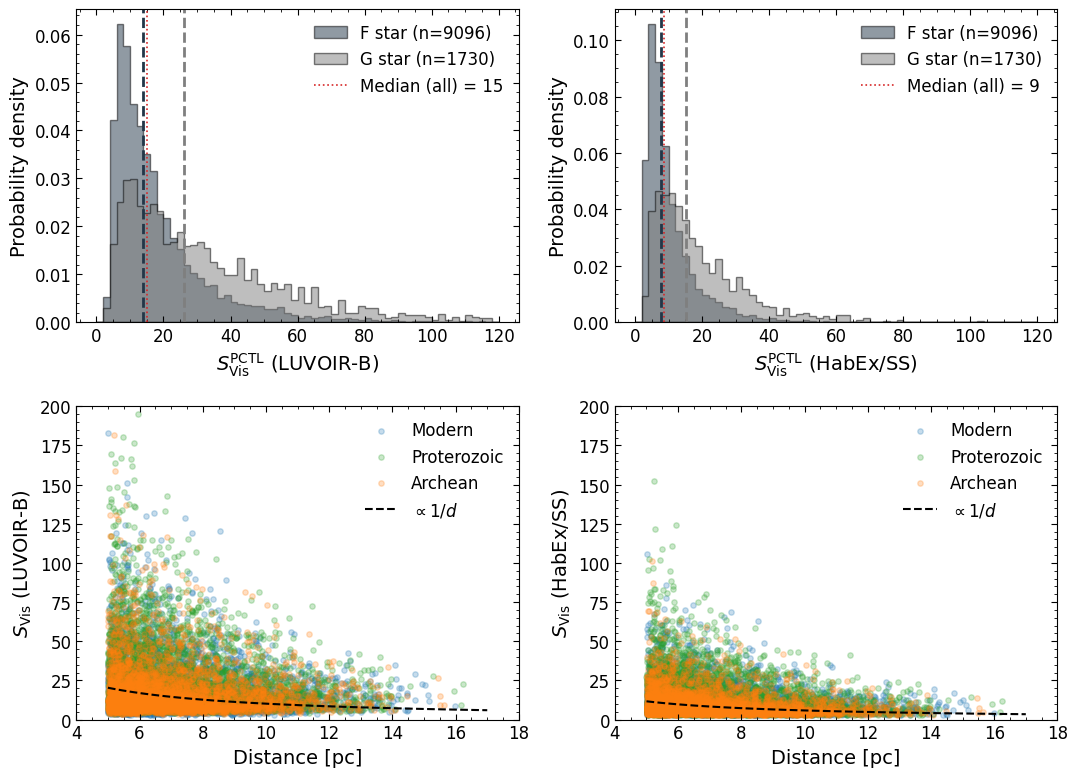

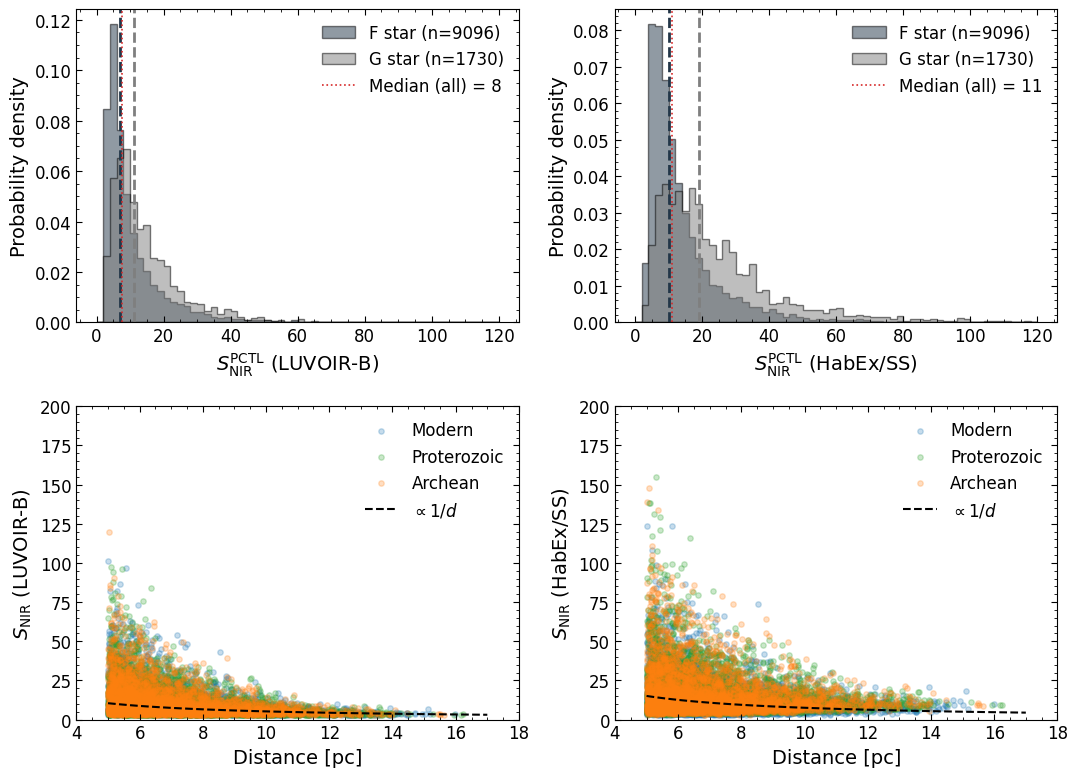

In [6]:
star_colors = {"F": "#223648", "G": "tab:gray"}

tel_snr_col = {
    "LUVOIR": {
        "Vis": "SNR_FEATURE_PCTL_B-Vis",
        "UV": "SNR_FEATURE_PCTL_B-UV",
        "NIR": "SNR_FEATURE_PCTL_B-NIR",
    },
    "HABEX": {
        "Vis": "SNR_FEATURE_PCTL_SS-Vis",
        "UV": "SNR_FEATURE_PCTL_SS-UV",
        "NIR": "SNR_FEATURE_PCTL_SS-NIR",
    },
}

tel_labels = {"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}
bands = ["UV", "Vis", "NIR"]

hist_range = (0, 120)
scatter_ylim = (0, 200)

for band in bands:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    for col, tel in enumerate(["LUVOIR", "HABEX"]):
        snr_col = tel_snr_col[tel][band]

        ax = axes[0, col]
        for st in ["F", "G"]:
            mask = meta_df["star_type"] == st
            vals = meta_df.loc[mask, snr_col].dropna()

            ax.hist(
                vals,
                bins=60,
                range=hist_range,
                density=True,
                color=star_colors[st],
                alpha=0.5,
                label=f"{st} star (n={vals.shape[0]})",
                histtype="stepfilled",
                edgecolor="k",
            )

            if len(vals) > 0:
                ax.axvline(vals.median(), color=star_colors[st], lw=2, ls="--")

        med_all = meta_df[snr_col].median()
        if pd.notna(med_all):
            ax.axvline(
                med_all,
                color="tab:red",
                lw=1.2,
                ls=":",
                label=f"Median (all) = {med_all:.0f}",
            )

        ax.set_xlabel(f"$S_{{\\rm {band}}}^{{\\rm PCTL}}$ ({tel_labels[tel]})")
        ax.set_ylabel("Probability density")
        ax.legend()

        ax = axes[1, col]
        for era in ERA_ORDER:
            mask = meta_df["era"] == era
            ax.scatter(
                meta_df.loc[mask, "distance_pc"],
                meta_df.loc[mask, snr_col],
                s=15,
                alpha=0.25,
                color=ERA_COLORS[era],
                label=era.capitalize(),
                rasterized=True,
            )

        d_arr = np.linspace(5, 17, 100)
        ref_d = meta_df["distance_pc"].median()
        ref_s = meta_df[snr_col].median()
        if pd.notna(ref_d) and pd.notna(ref_s) and ref_d > 0:
            ax.plot(d_arr, ref_s * ref_d / d_arr, "k--", lw=1.5, label=r"$\propto 1/d$")

        ax.set_xlabel("Distance [pc]")
        ax.set_ylabel(f"$S_{{\\rm {band}}}$ ({tel_labels[tel]})")
        ax.set_xlim(4, 18)
        ax.set_ylim(*scatter_ylim)
        ax.legend()

    fig.tight_layout()
    fig.savefig(f"../images/snr_distribution_{band.lower()}.pdf", bbox_inches="tight")
    plt.show()

## Retrieval Uncertainty vs. SNR

The bootstrap was run at four noise-scale factors $s \in \{0.5, 1.0, 2.0, 4.0\}$. Each factor multiplies the stored photon-noise vector before re-drawing noise realisations:
$$
\tilde{A}^{(b)} = A + s \cdot \varepsilon^{(b)},\quad \varepsilon^{(b)} \sim \mathcal{N}(0,\,\sigma_{\rm noise}^2)
$$
The effective percentile SNR at scale $s$ is therefore
$$
S_{\rm eff}(s) = \frac{\bar{S}_{\rm PCTL}}{s}
$$
where $\bar{S}_{\rm PCTL}$ is the sample-median baseline PCTL SNR.

For each parameter $j$ and telescope, we fit
$$
\sigma_{\rm data,j}(S_{\rm eff}) = a_j \cdot S_{\rm eff}^{-\alpha_j}
$$
using `scipy.optimize.curve_fit` (Levenberg–Marquardt, initial guess $a=0.5, \alpha=1$). The index $\alpha_j$ characterises how sensitive parameter $j$'s retrieval is to SNR:
- $\alpha = 1$: linear (photon-noise-limited, ideal behaviour)
- $\alpha > 1$: super-linear improvement (amplified by non-linear spectral features)
- $\alpha < 1$: sub-linear (model/degeneracy-limited even at high SNR)

In the photon-limited regime $\text{SNR} \propto D$ (aperture diameter), so:
$$
S_{\rm HWO} = S_{\rm ref} \times \frac{D_{\rm HWO}}{D_{\rm ref}}
$$
Two reference estimates are computed:
$$
S_{\rm HWO}^{\rm (LU)} = \bar{S}_{\rm LU} \times \frac{6}{8} = 11.2, \qquad S_{\rm HWO}^{\rm (HB)} = \bar{S}_{\rm HB} \times \frac{6}{4} = 12.9
$$
The geometric mean $S_{\rm HWO} = \sqrt{S^{\rm (LU)} \cdot S^{\rm (HB)}}$ is used as the single HWO operating point, with the spread between the two estimates forming a natural uncertainty band.

In [7]:
BANDS = ["UV", "Vis", "NIR"]
TELESCOPES = ["LUVOIR", "HABEX"]

SNR_COLS = {
    "LUVOIR": {
        "UV": "SNR_FEATURE_PCTL_B-UV",
        "Vis": "SNR_FEATURE_PCTL_B-Vis",
        "NIR": "SNR_FEATURE_PCTL_B-NIR",
    },
    "HABEX": {
        "UV": "SNR_FEATURE_PCTL_SS-UV",
        "Vis": "SNR_FEATURE_PCTL_SS-Vis",
        "NIR": "SNR_FEATURE_PCTL_SS-NIR",
    },
}

SNR_BASELINES = {
    tel: {band: float(np.median(meta_df[SNR_COLS[tel][band]])) for band in BANDS}
    for tel in TELESCOPES
}

print("Baseline SNR:")
for band in BANDS:
    print(
        f"  {band}: LUVOIR={SNR_BASELINES['LUVOIR'][band]:.1f}, "
        f"HabEx={SNR_BASELINES['HABEX'][band]:.1f}"
    )

snr_eff = {
    tel: {
        band: np.array([SNR_BASELINES[tel][band] / s for s in SNR_SCALES])
        for band in BANDS
    }
    for tel in TELESCOPES
}

med_std = {
    tel: {
        band: np.array(
            [
                [np.median(std_data[tel][s][:, j]) for s in SNR_SCALES]
                for j in range(N_PARAMS)
            ]
        )
        for band in BANDS
    }
    for tel in TELESCOPES
}


def power_law(snr, a, alpha):
    return a * snr ** (-alpha)


fit_params = {tel: {band: {} for band in BANDS} for tel in TELESCOPES}
for tel in TELESCOPES:
    for band in BANDS:
        for j in range(N_PARAMS):
            x = snr_eff[tel][band]
            y = med_std[tel][band][j]
            try:
                popt, _ = curve_fit(power_law, x, y, p0=[0.5, 1.0], maxfev=5000)
                fit_params[tel][band][j] = popt
            except RuntimeError:
                fit_params[tel][band][j] = np.array([np.nan, np.nan])


SNR_HWO = {}
for band in BANDS:
    snr_hwo_from_luvoir = SNR_BASELINES["LUVOIR"][band] * (
        HWO_APERTURE_M / TELESCOPE_CONFIG["LUVOIR"]["aperture_m"]
    )
    snr_hwo_from_habex = SNR_BASELINES["HABEX"][band] * (
        HWO_APERTURE_M / TELESCOPE_CONFIG["HABEX"]["aperture_m"]
    )
    SNR_HWO[band] = np.sqrt(snr_hwo_from_luvoir * snr_hwo_from_habex)

    print(f"\nHWO effective SNR ({band}):")
    print(f"  from LUVOIR scaling: {snr_hwo_from_luvoir:.1f}")
    print(f"  from HabEx  scaling: {snr_hwo_from_habex:.1f}")
    print(f"  geometric mean used: {SNR_HWO[band]:.1f}")

rows = []
for band in BANDS:
    for j, p in enumerate(PARAM_LABELS):
        rows.append(
            {
                "Band": band,
                "Parameter": p,
                "alfa (LUVOIR)": round(fit_params["LUVOIR"][band][j][1], 2),
                "alfa (HabEx)": round(fit_params["HABEX"][band][j][1], 2),
            }
        )

alpha_table = pd.DataFrame(rows).set_index(["Band", "Parameter"])
print("\nPower-law indices (sigma_data approx SNR^{-alfa}):")
alpha_table

Baseline SNR:
  UV: LUVOIR=25.6, HabEx=44.0
  Vis: LUVOIR=15.0, HabEx=8.6
  NIR: LUVOIR=7.7, HabEx=11.1

HWO effective SNR (UV):
  from LUVOIR scaling: 19.2
  from HabEx  scaling: 66.0
  geometric mean used: 35.6

HWO effective SNR (Vis):
  from LUVOIR scaling: 11.3
  from HabEx  scaling: 12.9
  geometric mean used: 12.1

HWO effective SNR (NIR):
  from LUVOIR scaling: 5.8
  from HabEx  scaling: 16.7
  geometric mean used: 9.8

Power-law indices (sigma_data approx SNR^{-alfa}):


alfa (LUVOIR)  alfa (HabEx)
Band Parameter                                  
UV   R$_\oplus$               0.86          0.84
     $g$                      0.84          0.80
     $T_{\rm surf}$           0.73          0.50
     $P_{\rm surf}$           0.84          0.75
     O$_2$                    1.02          1.13
     O$_3$                    1.25          1.28
     CH$_4$                   0.93          0.92
     CO$_2$                   0.94          1.01
     H$_2$O                   0.92          0.97
     N$_2$                    1.10          1.14
Vis  R$_\oplus$               0.86          0.84
     $g$                      0.84          0.80
     $T_{\rm surf}$           0.73          0.50
     $P_{\rm surf}$           0.84          0.75
     O$_2$                    1.02          1.13
     O$_3$                    1.25          1.28
     CH$_4$                   0.93          0.92
     CO$_2$                   0.94          1.01
     H$_2$O                   0.92          0.97
     N$_2$                    1.10          1.14
NIR  R$_\oplus$               0.86          0.84
     $g$                      0.84          0.80
     $T_{\rm surf}$           0.73          0.50
     $P_{\rm surf}$           0.84          0.75
     O$_2$                    1.02          1.13
     O$_3$                    1.25          1.28
     CH$_4$                   0.93          0.92
     CO$_2$                   0.94          1.01
     H$_2$O                   0.92          0.97
     N$_2$                    1.10          1.14

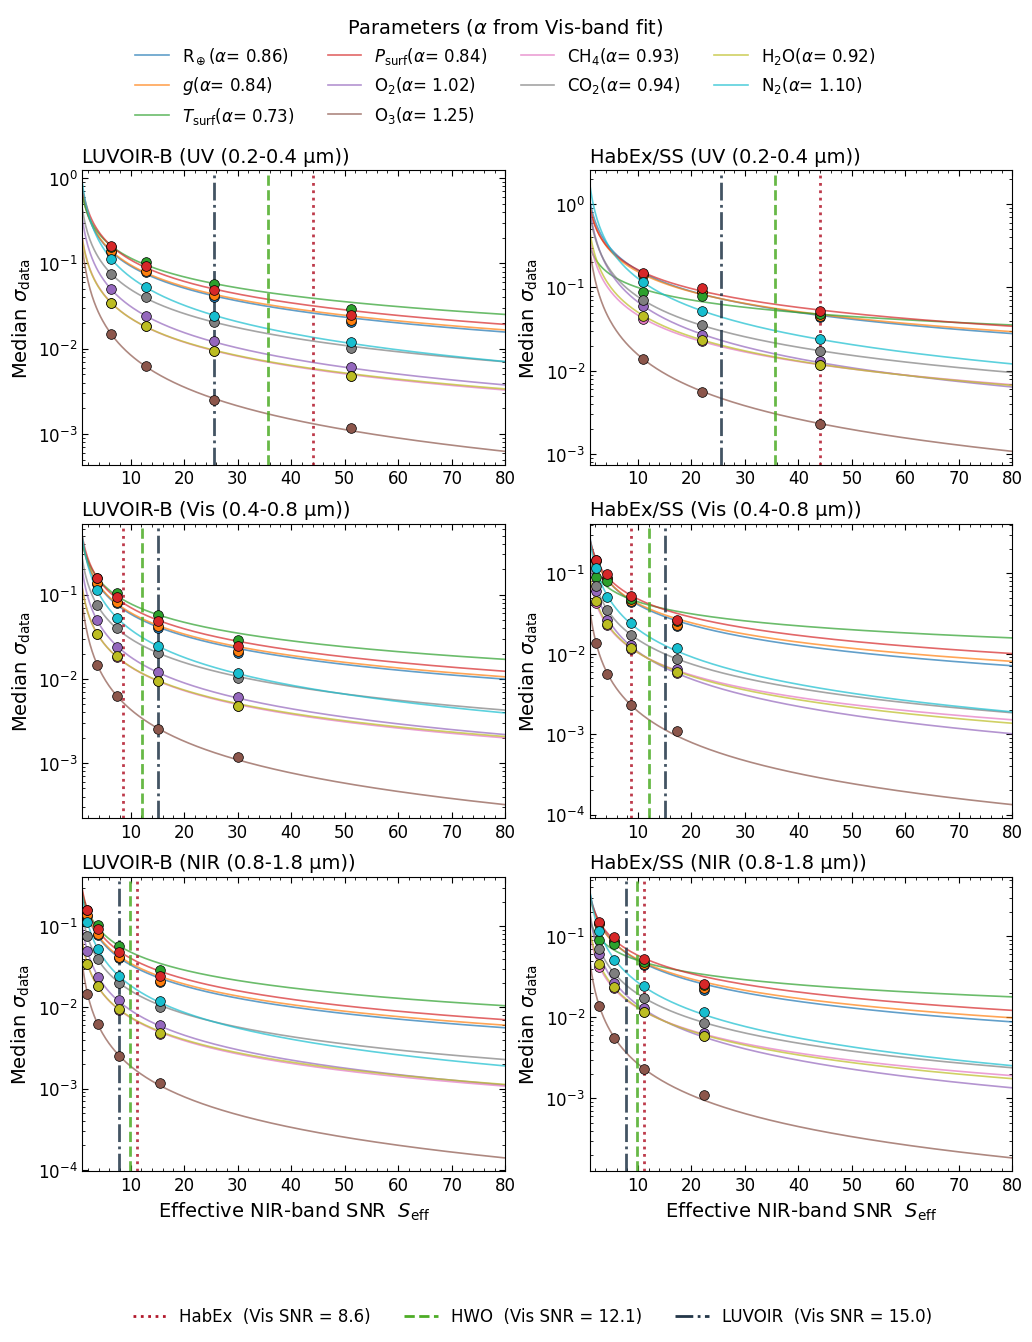

In [8]:
# The bootstrap applies uniform noise scaling to ALL bands simultaneously, so
# sigma_data values are identical across bands.

BAND_LABELS = {
    "UV": "UV (0.2-0.4 µm)",
    "Vis": "Vis (0.4-0.8 µm)",
    "NIR": "NIR (0.8-1.8 µm)",
}

mission_col = {
    "HabEx": TEL_COLORS["HABEX"],
    "HWO": TEL_COLORS["HWO"],
    "LUVOIR": TEL_COLORS["LUVOIR"],
}
mission_ls = {"HabEx": ":", "HWO": "--", "LUVOIR": "-."}

# Canonical Vis-band mission SNRs (used as reference in all downstream analysis)
mission_snr_vis = {
    "HabEx": SNR_BASELINES["HABEX"]["Vis"],
    "HWO": SNR_HWO["Vis"],
    "LUVOIR": SNR_BASELINES["LUVOIR"]["Vis"],
}

snr_cont = np.linspace(1, 80, 400)

fig, axes = plt.subplots(3, 2, figsize=(12, 13))

for row, band in enumerate(["UV", "Vis", "NIR"]):
    mission_snr_band = {
        "HabEx": SNR_BASELINES["HABEX"][band],
        "HWO": SNR_HWO[band],
        "LUVOIR": SNR_BASELINES["LUVOIR"][band],
    }
    for col, tel in enumerate(["LUVOIR", "HABEX"]):
        ax = axes[row, col]

        for j in range(N_PARAMS):
            ax.plot(
                snr_eff[tel][band],
                med_std[tel][band][j],
                "o",
                color=PARAM_COLORS[j],
                ms=7,
                markeredgecolor="k",
                markeredgewidth=0.5,
                zorder=3,
            )
            a, alpha = fit_params[tel][band][j]
            if not np.isnan(a):
                label = (
                    f"{PARAM_LABELS[j]}" + r"($\alpha$" + f"= {alpha:.2f})"
                    if (band == "Vis" and col == 0)
                    else None
                )
                ax.plot(
                    snr_cont,
                    power_law(snr_cont, a, alpha),
                    "-",
                    color=PARAM_COLORS[j],
                    lw=1.2,
                    alpha=0.7,
                    label=label,
                )

        for mission, snr_ref in mission_snr_band.items():
            ax.axvline(
                snr_ref,
                color=mission_col[mission],
                lw=2,
                ls=mission_ls[mission],
                alpha=0.85,
            )

        ax.set_yscale("log")
        tel_lbl = "LUVOIR-B" if tel == "LUVOIR" else "HabEx/SS"
        ax.set_title(f"{tel_lbl} ({BAND_LABELS[band]})", loc="left")
        ax.set_xlim(1, 80)
        if row == 2:
            ax.set_xlabel(rf"Effective {band}-band SNR  $S_{{\rm eff}}$")
        ax.set_ylabel(r"Median $\sigma_{{\rm data}}$")

axes[1, 0].legend(
    ncols=4,
    loc="lower center",
    title=r"Parameters ($\alpha$ from Vis-band fit)",
    bbox_to_anchor=(1, 2.3),
)

from matplotlib.lines import Line2D as _L2D

mission_lines = [
    _L2D(
        [0],
        [0],
        color=mission_col[m],
        lw=2,
        ls=mission_ls[m],
        label=f"{m}  (Vis SNR = {mission_snr_vis[m]:.1f})",
    )
    for m in ["HabEx", "HWO", "LUVOIR"]
]
fig.legend(
    handles=mission_lines,
    loc="lower center",
    ncols=3,
    bbox_to_anchor=(0.5, -0.02),
)
fig.savefig("../images/sigma_vs_snr.pdf", bbox_inches="tight")
plt.show()

# Molecular Detection Thresholds

For an unbiased retrieval, the predicted mean $\hat{z}_j \approx z_{\rm true,j}$. The *detection significance* of parameter $j$ for a given sample is defined as:
$$
\mathcal{S}_j = \frac{z_{\rm true,j}}{\sigma_{\rm total,j}}
$$
A molecule is *detected at $\kappa\sigma$* when $\mathcal{S}_j > \kappa$. We use $\kappa = 3$ as the primary threshold.

This is equivalent to requiring that the $\kappa\sigma$ credible interval $[\hat{z}_j - \kappa\sigma_{\rm total}, \hat{z}_j + \kappa\sigma_{\rm total}]$ **does not include zero**, i.e., the molecule is confidently distinguished from absence.

For a geological era $E$ and molecule $j$:
$$
f_{\rm det}(E, j, s, \kappa) = \frac{\#\{i \in E :\, z_{\rm true,j}^{(i)} > 0\;\text{and}\;\mathcal{S}_j^{(i)} > \kappa\}} {\#\{i \in E :\, z_{\rm true,j}^{(i)} > 0\}}
$$
Only samples where the molecule is actually *present* ($z_{\rm true} > 0$) enter the denominator. Archean O$_2$ and O$_3$ are exactly zero and therefore excluded, returning `NaN`.

At noise scale $s$, the per-sample total uncertainty is 
$$
\sigma_{\rm total,j}(s) = \sqrt{\sigma_{\rm model,j}^2 + \sigma_{\rm data,j}^2(s)}
$$
where $\sigma_{\rm model,j}$ is fixed (scale-independent MC-dropout estimate) and $\sigma_{\rm data,j}(s)$ comes from the bootstrap at that scale. 

In [9]:
def detection_fraction(tel, scale, era=None, threshold=DETECTION_SIGMA):
    """Fraction of samples with detection significance > threshold."""
    s_data = std_data[tel][scale]
    s_model = sigma_model[tel]
    s_total = np.sqrt(s_model**2 + s_data**2)

    sig = np.where(s_total > 0, z_true / s_total, 0.0)

    if era is None:
        return (sig > threshold).mean(axis=0)
    mask = meta_df["era"].values == era
    # Only include samples where the molecule is actually present (z_true > 0)
    present = z_true[mask] > 0
    detected = sig[mask] > threshold
    with np.errstate(invalid="ignore"):
        frac = np.where(
            present.sum(axis=0) > 0,
            (detected & present).sum(axis=0) / present.sum(axis=0),
            np.nan,
        )
    return frac


det_frac = {
    tel: {
        s: {era: detection_fraction(tel, s, era) for era in ERA_ORDER + [None]}
        for s in SNR_SCALES
    }
    for tel in ["LUVOIR", "HABEX"]
}

/tmp/ipykernel_97867/4226855199.py:7: RuntimeWarning: divide by zero encountered in divide
  sig = np.where(s_total > 0, z_true / s_total, 0.0)
/tmp/ipykernel_97867/4226855199.py:7: RuntimeWarning: invalid value encountered in divide
  sig = np.where(s_total > 0, z_true / s_total, 0.0)


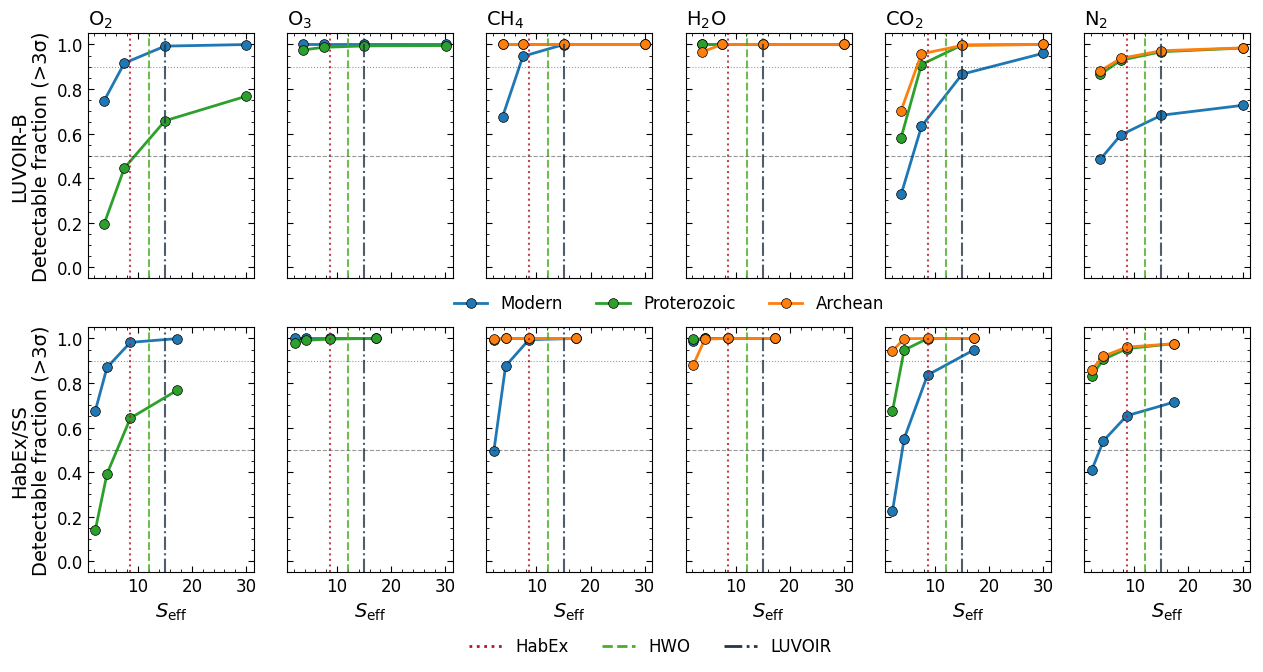

In [10]:
BIOSIGS = ["O2", "O3", "CH4", "H2O", "CO2", "N2"]

fig, axes = plt.subplots(2, len(BIOSIGS), figsize=(15, 7), sharex=True, sharey=True)

for row, tel in enumerate(["LUVOIR", "HABEX"]):
    snr_x = snr_eff[tel]["Vis"]

    for col, mol in enumerate(BIOSIGS):
        j = CHEM_IDX[mol]
        ax = axes[row, col]

        for era in ERA_ORDER:
            fracs = [det_frac[tel][s][era][j] for s in SNR_SCALES]
            ax.plot(
                snr_x,
                fracs,
                "o-",
                color=ERA_COLORS[era],
                lw=2,
                ms=7,
                markeredgecolor="k",
                markeredgewidth=0.5,
                label=era.capitalize(),
            )

        ax.axvline(
            mission_snr_vis["HabEx"],
            color=TEL_COLORS["HABEX"],
            lw=1.5,
            ls=":",
            alpha=0.8,
        )
        ax.axvline(
            mission_snr_vis["HWO"], color=TEL_COLORS["HWO"], lw=1.5, ls="--", alpha=0.8
        )
        ax.axvline(
            mission_snr_vis["LUVOIR"],
            color=TEL_COLORS["LUVOIR"],
            lw=1.5,
            ls="-.",
            alpha=0.8,
        )

        ax.axhline(0.5, color="k", lw=0.8, ls="--", alpha=0.4)
        ax.axhline(0.9, color="k", lw=0.8, ls=":", alpha=0.4)

        if row == 0:
            ax.set_title(CHEM_LABEL[mol], loc="left")
        if col == 0:
            tel_lbl = {"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel]
            ax.set_ylabel(f"{tel_lbl}\nDetectable fraction (>{DETECTION_SIGMA:.0f}σ)")
        if row == 1:
            ax.set_xlabel("$S_{\\rm eff}$")
        if row == 0 and col == len(BIOSIGS) - 3:
            ax.legend(
                loc="lower center",
                ncols=3,
                bbox_to_anchor=(-0.1, -0.2),
            )
        ax.set_ylim(-0.05, 1.05)

leg_patches = [
    Line2D([0], [0], color=TEL_COLORS["HABEX"], lw=2, ls=":", label="HabEx"),
    Line2D([0], [0], color=TEL_COLORS["HWO"], lw=2, ls="--", label="HWO"),
    Line2D([0], [0], color=TEL_COLORS["LUVOIR"], lw=2, ls="-.", label="LUVOIR"),
]
fig.legend(
    handles=leg_patches,
    loc="lower center",
    ncols=3,
    bbox_to_anchor=(0.5, -0.03),
)

fig.savefig("../images/detection_fraction_vs_snr.pdf", bbox_inches="tight")
plt.show()

In [11]:
def min_snr_for_fraction(tel, mol, era, target_frac=0.5):
    """Interpolate the minimum SNR at which the detectable fraction exceeds target_frac"""
    j = CHEM_IDX[mol]
    x = snr_eff[tel]["Vis"]
    y = np.array([det_frac[tel][s][era][j] for s in SNR_SCALES])
    # Sort by increasing SNR
    idx = np.argsort(x)
    x, y = x[idx], y[idx]
    if y.max() < target_frac:
        return np.nan
    if y.min() >= target_frac:
        return x.min()
    # Linear interpolation between the first crossing pair
    for k in range(len(y) - 1):
        if y[k] < target_frac <= y[k + 1]:
            t = (target_frac - y[k]) / (y[k + 1] - y[k])
            return x[k] + t * (x[k + 1] - x[k])
    return np.nan


rows = []
for mol in BIOSIGS:
    for era in ERA_ORDER:
        row = {"Molecule": CHEM_LABEL[mol], "Era": era.capitalize()}
        for tel in ["LUVOIR", "HABEX"]:
            snr50 = min_snr_for_fraction(tel, mol, era, 0.50)
            snr90 = min_snr_for_fraction(tel, mol, era, 0.90)
            tl = {"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel]
            row[f"{tl} SNR₅₀"] = f"{snr50:.0f}" if not np.isnan(snr50) else ">60"
            row[f"{tl} SNR₉₀"] = f"{snr90:.0f}" if not np.isnan(snr90) else ">60"
        rows.append(row)

tbl = pd.DataFrame(rows).set_index(["Molecule", "Era"])
print("Minimum SNR for ≥50% / ≥90% detectable fraction (3σ criterion)")
tbl

Minimum SNR for ≥50% / ≥90% detectable fraction (3σ criterion)


LUVOIR-B SNR₅₀ LUVOIR-B SNR₉₀ HabEx/SS SNR₅₀  \
Molecule Era                                                        
O$_2$    Modern                   4              7              2   
         Proterozoic              9            >60              6   
         Archean                >60            >60            >60   
O$_3$    Modern                   4              4              2   
         Proterozoic              4              4              2   
         Archean                >60            >60            >60   
CH$_4$   Modern                   4              7              2   
         Proterozoic              4              4              2   
         Archean                  4              4              2   
H$_2$O   Modern                   4              4              2   
         Proterozoic              4              4              2   
         Archean                  4              4              2   
CO$_2$   Modern                   6             20              4   
         Proterozoic              4              7              2   
         Archean                  4              7              2   
N$_2$    Modern                   4            >60              4   
         Proterozoic              4              6              2   
         Archean                  4              5              2   

                     HabEx/SS SNR₉₀  
Molecule Era                         
O$_2$    Modern                   5  
         Proterozoic            >60  
         Archean                >60  
O$_3$    Modern                   2  
         Proterozoic              2  
         Archean                >60  
CH$_4$   Modern                   5  
         Proterozoic              2  
         Archean                  2  
H$_2$O   Modern                   2  
         Proterozoic              2  
         Archean                  3  
CO$_2$   Modern                  14  
         Proterozoic              4  
         Archean                  2  
N$_2$    Modern                 >60  
         Proterozoic              4  
         Archean                  4

each cell reports the minimum effective SNR required to detect $\geq 50$% ($\text{SNR}_{50}$) or $\geq 90\%$ (SNR$_{90}$) of all present-abundance samples at $3\sigma$.

In [12]:
corr_model = {
    tel: {
        era: np.corrcoef(sigma_model[tel][meta_df["era"].values == era].T)
        for era in ERA_ORDER
    }
    for tel in ["LUVOIR", "HABEX"]
}

for tel in ["LUVOIR", "HABEX"]:
    corr_model[tel]["all"] = np.corrcoef(sigma_model[tel].T)

# Show the strongest degeneracy pairs
C = corr_model["LUVOIR"]["all"]
pairs = []
for i in range(N_PARAMS):
    for j in range(i + 1, N_PARAMS):
        pairs.append(
            {"Param A": PARAM_LABELS[i], "Param B": PARAM_LABELS[j], "r": C[i, j]}
        )
df_pairs = pd.DataFrame(pairs).sort_values("r", ascending=False, key=abs)
print("Top 10 epistemic degeneracy pairs (LUVOIR, all eras):")
df_pairs.head(10).set_index(["Param A", "Param B"])

Top 10 epistemic degeneracy pairs (LUVOIR, all eras):


,,r
Param A,Param B,
R$_\oplus$,$g$,0.967770
$g$,$P_{\rm surf}$,0.897581
R$_\oplus$,$P_{\rm surf}$,0.758983
CH$_4$,H$_2$O,0.742635
CO$_2$,H$_2$O,0.672918
CH$_4$,CO$_2$,0.655297
CO$_2$,N$_2$,0.556964
O$_2$,N$_2$,0.556819
R$_\oplus$,H$_2$O,0.472674


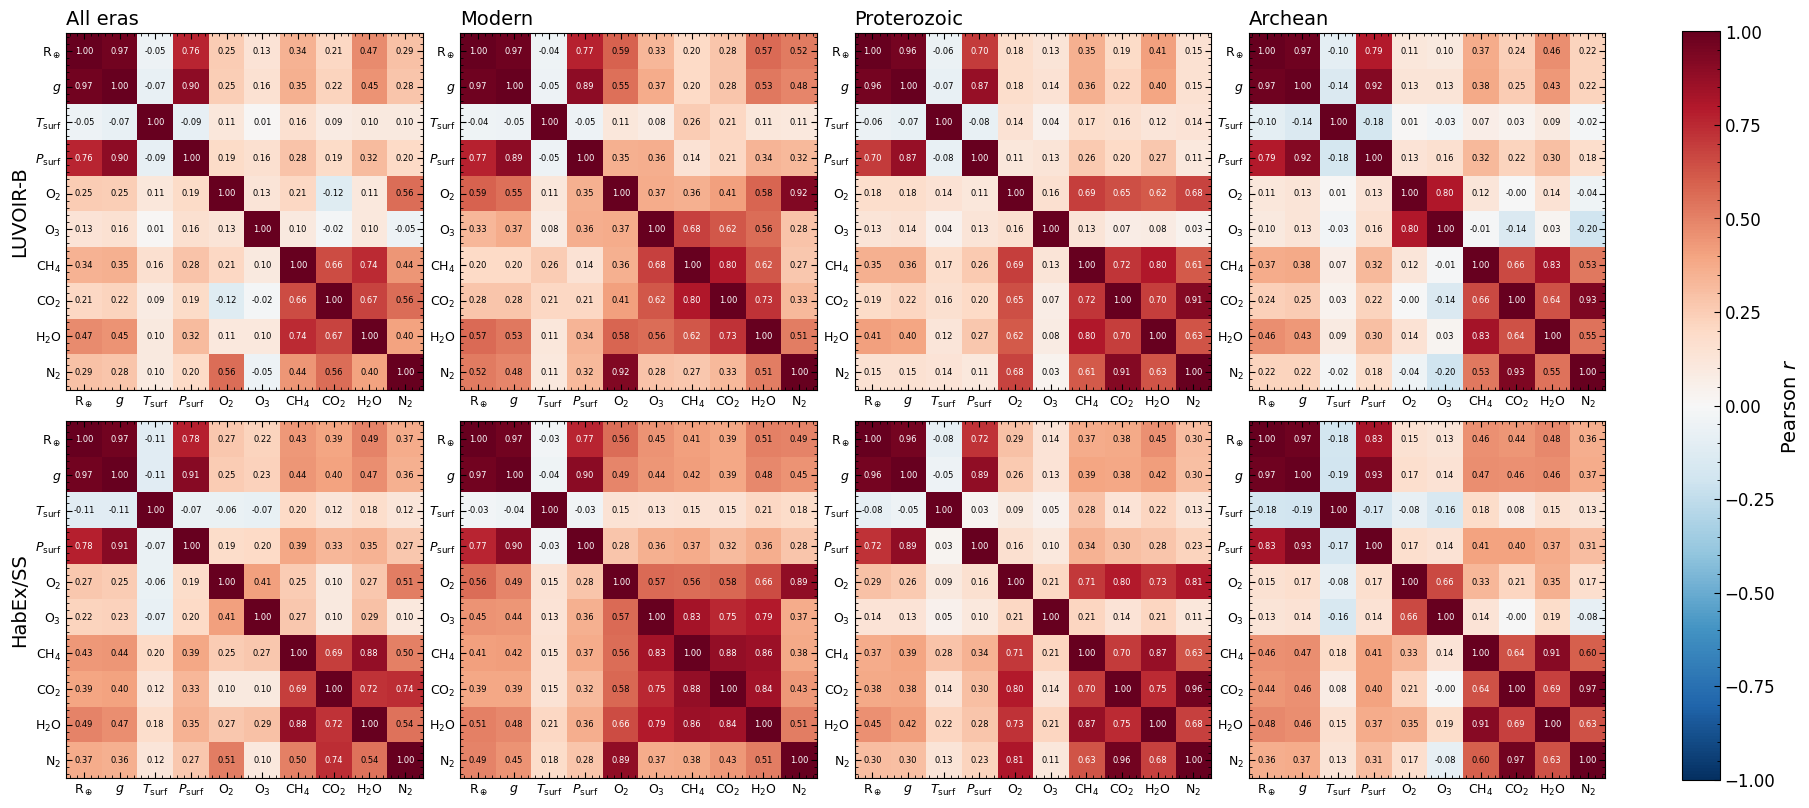

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)

cmap_div = "RdBu_r"
era_titles = {
    "modern": "Modern",
    "proterozoic": "Proterozoic",
    "archean": "Archean",
    "all": "All eras",
}

for row, tel in enumerate(["LUVOIR", "HABEX"]):
    for col, key in enumerate(["all", "modern", "proterozoic", "archean"]):
        ax = axes[row, col]
        C = corr_model[tel][key]

        im = ax.imshow(C, cmap=cmap_div, vmin=-1, vmax=1, aspect="equal")
        ax.set_xticks(range(N_PARAMS))
        ax.set_yticks(range(N_PARAMS))
        ax.set_xticklabels(PARAM_LABELS, fontsize=9)
        ax.set_yticklabels(PARAM_LABELS, fontsize=9)

        for i in range(N_PARAMS):
            for j in range(N_PARAMS):
                val = C[i, j]
                txt_col = "w" if abs(val) > 0.6 else "k"
                ax.text(
                    j,
                    i,
                    f"{val:.2f}",
                    ha="center",
                    va="center",
                    fontsize=6,
                    color=txt_col,
                )

        if row == 0:
            ax.set_title(era_titles[key], loc="left")
        if col == 0:
            ax.set_ylabel({"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel])

fig.colorbar(im, ax=axes, label="Pearson $r$")
fig.savefig("../images/degeneracy_correlation.pdf", bbox_inches="tight")
plt.show()

# Distance and Stellar Type Dependence

In the photon-limited regime, the noise amplitude scales as $\sigma_{\rm noise} \propto d$ for fixed aperture and integration time. Consequently, the bootstrap noise-scale factor $s$ is physically equivalent to observing the same planet at a *scaled distance*:
$$
d_{\rm equiv} = s \times d_{\rm actual}
$$
This allows us to use the four bootstrap scales as four effective distance samples for each test planet.

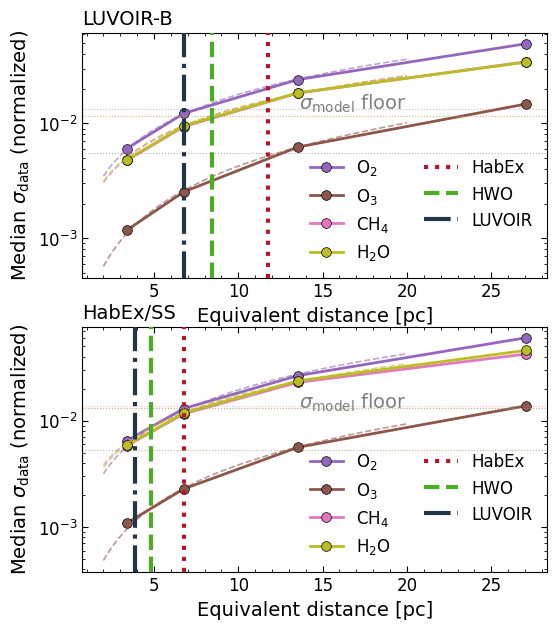

In [14]:
D_BIOSIGS = ["O2", "O3", "CH4", "H2O"]

fig, axes = plt.subplots(2, 1, figsize=(6, 7), sharey=False)

for ax, tel in zip(axes, ["LUVOIR", "HABEX"]):
    for mol in D_BIOSIGS:
        j = CHEM_IDX[mol]
        # Median d_equiv at each scale = d_actual * scale  (median over sample)
        d_equiv = [np.median(meta_df["distance_pc"].values * s) for s in SNR_SCALES]
        med_sig = [np.median(std_data[tel][s][:, j]) for s in SNR_SCALES]

        col = PARAM_COLORS[j]
        ax.plot(
            d_equiv,
            med_sig,
            "o-",
            color=col,
            lw=2,
            ms=7,
            markeredgecolor="k",
            markeredgewidth=0.5,
            label=CHEM_LABEL[mol],
        )

        # Extend with power-law fit
        a, alpha = fit_params[tel]["Vis"][j]
        if not np.isnan(a):
            # Convert distance to effective SNR: S = S_baseline * d_ref / d
            d_ref_med = np.median(meta_df["distance_pc"].values)
            d_plot = np.linspace(2, 20, 200)
            snr_d = SNR_BASELINES[tel]["Vis"] * (d_ref_med / d_plot)
            ax.plot(
                d_plot, power_law(snr_d, a, alpha), "--", color=col, lw=1.2, alpha=0.6
            )

    # Sigma_model floor (SNR-independent)
    for mol in D_BIOSIGS:
        j = CHEM_IDX[mol]
        sig_floor = np.median(sigma_model[tel][:, j])
        ax.axhline(sig_floor, color=PARAM_COLORS[j], lw=0.8, ls=":", alpha=0.5)

    # Mission distance reference lines
    for mission, snr_ref in mission_snr_vis.items():
        d_ref_med = np.median(meta_df["distance_pc"].values)
        d_mission = d_ref_med * SNR_BASELINES[tel]["Vis"] / snr_ref
        ax.axvline(
            d_mission,
            color=mission_col[mission],
            lw=3,
            ls=mission_ls[mission],
            label=f"{mission}",
            zorder=10,
        )

    ax.set_xlabel("Equivalent distance [pc]")
    ax.set_ylabel(r"Median $\sigma_{\rm data}$ (normalized)")
    ax.set_title({"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel], loc="left")
    ax.set_yscale("log")
    ax.legend(ncols=2)
    ax.annotate(
        "$\\sigma_{\\rm model}$ floor",
        xy=(20, np.median(sigma_model[tel][:, 4])),
        color="gray",
        ha="right",
    )

fig.savefig("../images/sigma_vs_distance.pdf", bbox_inches="tight")
plt.show()

Coloured curves show $\sigma_{\rm data}$ vs. equivalent distance for four key biosignatures, dashed extensions extrapolate via the power-law fit, horizontal dotted lines mark the $\sigma_{\rm model}$ floor for each species. Mission vertical lines show at what equivalent distance each telescope currently operates on the median target.

The dotted floor for O2 ($\sigma_{\rm model} \approx 0.028$) and the condition $z_{\rm O_2,\rm modern}/\sigma_{\rm total} > 3$ with $z_{\rm O_2} \approx 0.56$ give a model-limited maximum horizon of approximately 
$$
d_{\rm max}^{\rm model} \approx 6.8\;\text{pc}\times \frac{\sqrt{(0.56/3)^2 - 0.028^2}}{0.027} \approx 40\;\text{pc}
$$
meaning that with perfect noise, O2 could be detected to $\sim40$ pc with LUVOIR. At current operating SNR the practical horizon is substantially shorter.


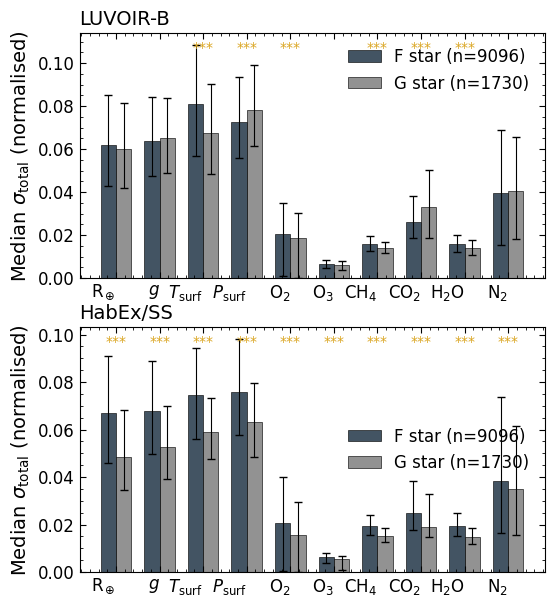

In [15]:
# F vs G stellar type comparison of sigma_total
star_mask = {
    "F": meta_df["star_type"].values == "F",
    "G": meta_df["star_type"].values == "G",
}
star_colors_map = {"F": "#223648", "G": "tab:gray"}

fig, axes = plt.subplots(2, 1, figsize=(6, 7), sharey=False)

for ax, tel in zip(axes, ["LUVOIR", "HABEX"]):
    x_pos = np.arange(N_PARAMS)
    width = 0.35

    for offset, st in zip([-width / 2, width / 2], ["F", "G"]):
        msk = star_mask[st]
        data = sigma_total_1x[tel][msk]  # (N_st, 10)
        med = np.median(data, axis=0)
        q25 = np.percentile(data, 25, axis=0)
        q75 = np.percentile(data, 75, axis=0)

        ax.bar(
            x_pos + offset,
            med,
            width,
            color=star_colors_map[st],
            alpha=0.85,
            edgecolor="k",
            linewidth=0.5,
            label=f"{st} star (n={msk.sum()})",
        )
        ax.errorbar(
            x_pos + offset,
            med,
            yerr=[med - q25, q75 - med],
            fmt="none",
            color="k",
            capsize=3,
            linewidth=0.8,
        )

    # Mann-Whitney U test per parameter
    for j in range(N_PARAMS):
        d_f = sigma_total_1x[tel][star_mask["F"], j]
        d_g = sigma_total_1x[tel][star_mask["G"], j]
        _, p = mannwhitneyu(d_f, d_g, alternative="two-sided")
        if p < 0.001:
            ax.text(
                j,
                ax.get_ylim()[1] * 0.97 if ax.get_ylim()[1] > 0 else 0.14,
                "***",
                ha="center",
                va="top",
                fontsize=10,
                color="goldenrod",
            )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(PARAM_LABELS, ha="right")
    ax.set_ylabel(r"Median $\sigma_{\rm total}$ (normalised)")
    ax.set_title({"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel], loc="left")
    ax.legend()

fig.savefig("../images/stellar_type_comparison.pdf", bbox_inches="tight")
plt.show()

# HWO Mission Context and Design Requirements

In the photon-noise-dominated regime, collecting area $\propto D^2$ and $\text{SNR} \propto \sqrt{\text{area}} = D$:
$$
\frac{S_{\rm HWO}}{S_{\rm ref}} = \frac{D_{\rm HWO}}{D_{\rm ref}} = \begin{cases} 6/8 = 0.75 & \text{(LUVOIR reference)} \\ 6/4 = 1.50 & \text{(HabEx reference)} \end{cases}
$$
HWO $\sigma_{\rm data}$ is estimated by evaluating the power-law fits at $S_{\rm HWO}^{\rm (LU)}$ and $S_{\rm HWO}^{\rm (HB)}$ and averaging.

We compare the *full* $\sigma_{\rm total} = \sqrt{\sigma_{\rm model}^2 + \sigma_{\rm data}^2}$ (not just $\sigma_{\rm data}$) because this is what an observer would measure as posterior width. The plot shows:
- HabEx at baseline $s = 1.0$
- HWO at the interpolated $\sigma_{\rm data}$, combined with the average $\sigma_{\rm model}$ from LUVOIR and HabEx
- LUVOIR at baseline $s = 1.0$

The percentage annotations show the improvement of HWO over HabEx:
$$
\Delta\sigma_{\rm total}^{\rm HWO/HabEx} = \frac{\sigma_{\rm total}^{\rm HabEx} - \sigma_{\rm total}^{\rm HWO}}{\sigma_{\rm total}^{\rm HabEx}} \times 100\%
$$

For a planet at reference distance $d_{\rm ref}$ with stored noise $\sigma_{\rm data,ref}$, the maximum detectable distance at $\kappa\sigma$ is found by solving 
$$
\frac{z_{\rm true}}{\sqrt{\sigma_{\rm model}^2 + \sigma_{\rm data,ref}^2 \cdot (d/d_{\rm ref})^2}} = \kappa
$$
for $d$, yielding:
$$
d_{\rm max} = d_{\rm ref} \cdot \frac{\sqrt{(z_{\rm true}/\kappa)^2 - \sigma_{\rm model}^2}}{\sigma_{\rm data,ref}}
$$
This is computed per sample and the **median** is reported. Samples for which $\sigma_{\rm model} > z_{\rm true}/\kappa$ (model uncertainty alone exceeds the threshold) are excluded as `NaN`, these targets are intrinsically undetectable regardless of SNR.

The full SNR range $4 \leq S_{\rm eff} \leq 60$ is scanned:
$$
\sigma_{\rm total}(S_{\rm eff}) = \sqrt{\sigma_{\rm model}^2 + a\,S_{\rm eff}^{-\alpha}}
$$
The $\sigma_{\rm model}$ floor becomes visible as the high-SNR asymptote. Mission bands are shown as vertical shaded regions.

In [16]:
_snr_hwo_vis_lu = SNR_BASELINES["LUVOIR"]["Vis"] * (
    HWO_APERTURE_M / TELESCOPE_CONFIG["LUVOIR"]["aperture_m"]
)
_snr_hwo_vis_hb = SNR_BASELINES["HABEX"]["Vis"] * (
    HWO_APERTURE_M / TELESCOPE_CONFIG["HABEX"]["aperture_m"]
)

missions = {
    "HabEx/SS": {"snr": SNR_BASELINES["HABEX"]["Vis"], "tel": "HABEX", "aperture": 4.0},
    "HWO": {"snr": SNR_HWO["Vis"], "tel": None, "aperture": 6.0},
    "LUVOIR-B": {
        "snr": SNR_BASELINES["LUVOIR"]["Vis"],
        "tel": "LUVOIR",
        "aperture": 8.0,
    },
}


def sigma_data_at_snr(tel, j, snr_target, band="Vis"):
    # Predict sigma_data at a given SNR using the band power-law fit
    a, alpha = fit_params[tel][band][j]
    if np.isnan(a):
        return np.nan
    return power_law(snr_target, a, alpha)


def sigma_data_hwo(j):
    # Interpolate HWO sigma_data as average from LUVOIR and HabEx Vis-band fits
    s_lu = sigma_data_at_snr("LUVOIR", j, _snr_hwo_vis_lu)
    s_hb = sigma_data_at_snr("HABEX", j, _snr_hwo_vis_hb)
    return 0.5 * (s_lu + s_hb)


# sigma_model median (SNR-independent epistemic floor)
med_sigma_model = {
    tel: np.median(sigma_model[tel], axis=0) for tel in ["LUVOIR", "HABEX"]
}

rows = []
for j, p in enumerate(PARAM_LABELS):
    row = {"Parameter": p}
    # HabEx
    s_d = np.median(std_data["HABEX"][1.0][:, j])
    s_m = med_sigma_model["HABEX"][j]
    row["HabEx sigma_data"] = f"{s_d:.4f}"
    row["HabEx sigma_total"] = f"{np.sqrt(s_m**2 + s_d**2):.4f}"
    # HWO (interpolated)
    s_d_hwo = sigma_data_hwo(j)
    s_m_hwo = 0.5 * (med_sigma_model["LUVOIR"][j] + med_sigma_model["HABEX"][j])
    row["HWO sigma_data"] = f"{s_d_hwo:.4f}"
    row["HWO sigma_total"] = f"{np.sqrt(s_m_hwo**2 + s_d_hwo**2):.4f}"
    # LUVOIR
    s_d = np.median(std_data["LUVOIR"][1.0][:, j])
    s_m = med_sigma_model["LUVOIR"][j]
    row["LUVOIR sigma_data"] = f"{s_d:.4f}"
    row["LUVOIR sigma_total"] = f"{np.sqrt(s_m**2 + s_d**2):.4f}"
    rows.append(row)

summary_tbl = pd.DataFrame(rows).set_index("Parameter")
print("Mission performance comparison (median normalised uncertainties):")
summary_tbl

Mission performance comparison (median normalised uncertainties):


,HabEx sigma_data,HabEx sigma_total,HWO sigma_data,HWO sigma_total,LUVOIR sigma_data,LUVOIR sigma_total
Parameter,,,,,,
R$_\oplus$,0.0444,0.0608,0.0430,0.0601,0.0407,0.0587
$g$,0.0459,0.0623,0.0448,0.0621,0.0423,0.0610
$T_{\rm surf}$,0.0483,0.0685,0.0552,0.0737,0.0566,0.0749
$P_{\rm surf}$,0.0519,0.0704,0.0516,0.0713,0.0488,0.0706
O$_2$,0.0130,0.0185,0.0120,0.0178,0.0122,0.0180
O$_3$,0.0023,0.0058,0.0026,0.0060,0.0025,0.0060
CH$_4$,0.0116,0.0179,0.0102,0.0162,0.0094,0.0148
CO$_2$,0.0173,0.0234,0.0192,0.0248,0.0203,0.0257
H$_2$O,0.0118,0.0177,0.0103,0.0161,0.0095,0.0149


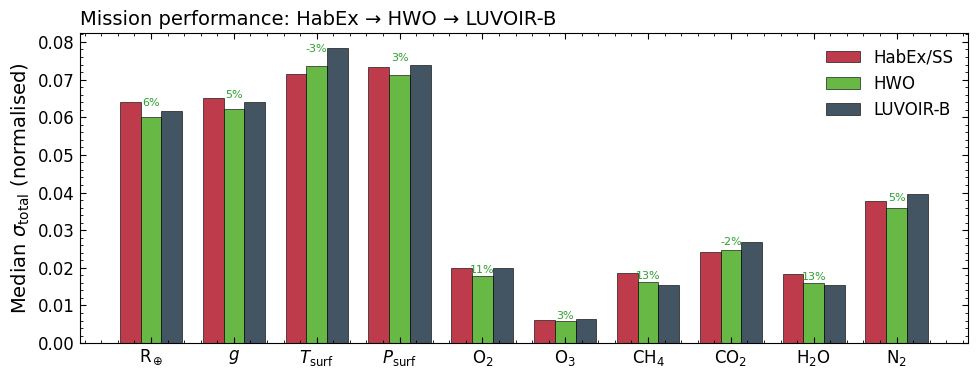

,HWO improvement over HabEx (%),LUVOIR improvement over HabEx (%)
Parameter,,
R$_\oplus$,6.2,4.0
$g$,4.6,1.6
$T_{\rm surf}$,-3.1,-9.5
$P_{\rm surf}$,2.9,-0.5
O$_2$,10.8,-0.4
O$_3$,2.6,-4.5
CH$_4$,13.0,17.5
CO$_2$,-2.5,-11.5
H$_2$O,12.7,16.2


In [17]:
mission_names = ["HabEx/SS", "HWO", "LUVOIR-B"]
mission_cols = [TEL_COLORS["HABEX"], TEL_COLORS["HWO"], TEL_COLORS["LUVOIR"]]

mission_sigma_total = []

s_d_hb = std_data["HABEX"][1.0]
s_m_hb = sigma_model["HABEX"]
mission_sigma_total.append(np.median(np.sqrt(s_m_hb**2 + s_d_hb**2), axis=0))

# HWO (interpolated)
hwo_sigma_total_vec = np.array(
    [
        np.sqrt(
            sigma_data_hwo(j) ** 2
            + (0.5 * (med_sigma_model["LUVOIR"][j] + med_sigma_model["HABEX"][j])) ** 2
        )
        for j in range(N_PARAMS)
    ]
)
mission_sigma_total.append(hwo_sigma_total_vec)

# LUVOIR at 1.0x
s_d_lu = std_data["LUVOIR"][1.0]
s_m_lu = sigma_model["LUVOIR"]
mission_sigma_total.append(np.median(np.sqrt(s_m_lu**2 + s_d_lu**2), axis=0))

fig, ax = plt.subplots(figsize=(10, 4))
x_pos = np.arange(N_PARAMS)
n_m = len(mission_names)
width = 0.25

for k, (name, col, med) in enumerate(
    zip(mission_names, mission_cols, mission_sigma_total)
):
    offset = (k - (n_m - 1) / 2) * width
    ax.bar(
        x_pos + offset,
        med,
        width,
        color=col,
        alpha=0.85,
        edgecolor="k",
        linewidth=0.5,
        label=name,
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(PARAM_LABELS)
ax.set_ylabel(r"Median $\sigma_{\rm total}$ (normalised)")
ax.set_title("Mission performance: HabEx → HWO → LUVOIR-B", loc="left")
ax.legend()

for j in range(N_PARAMS):
    improvement = (
        (mission_sigma_total[0][j] - mission_sigma_total[1][j])
        / mission_sigma_total[0][j]
        * 100
    )
    ax.annotate(
        f"{improvement:.0f}%",
        xy=(j + 0, mission_sigma_total[1][j]),
        xytext=(j + 0, mission_sigma_total[1][j] * 1.05),
        ha="center",
        color="tab:green",
        fontsize=8,
    )

fig.tight_layout()
fig.savefig("../images/mission_comparison.pdf", bbox_inches="tight")
plt.show()

imp_table = pd.DataFrame(
    {
        "Parameter": PARAM_LABELS,
        "HWO improvement over HabEx (%)": [
            f"{(mission_sigma_total[0][j] - mission_sigma_total[1][j]) / mission_sigma_total[0][j] * 100:.1f}"
            for j in range(N_PARAMS)
        ],
        "LUVOIR improvement over HabEx (%)": [
            f"{(mission_sigma_total[0][j] - mission_sigma_total[2][j]) / mission_sigma_total[0][j] * 100:.1f}"
            for j in range(N_PARAMS)
        ],
    }
).set_index("Parameter")
imp_table

/tmp/ipykernel_97867/3821212810.py:19: RuntimeWarning: divide by zero encountered in divide
  valid, d_ref * np.sqrt(np.where(valid, numerator, np.nan)) / s_d, np.nan
/tmp/ipykernel_97867/3821212810.py:19: RuntimeWarning: divide by zero encountered in divide
  valid, d_ref * np.sqrt(np.where(valid, numerator, np.nan)) / s_d, np.nan


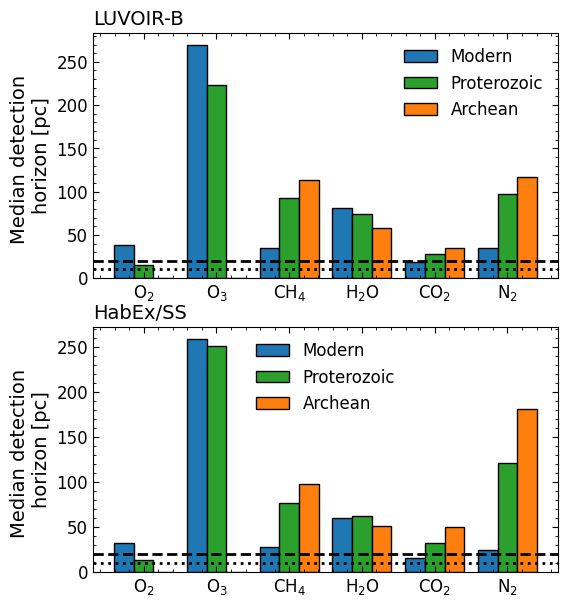

/tmp/ipykernel_97867/3821212810.py:19: RuntimeWarning: divide by zero encountered in divide
  valid, d_ref * np.sqrt(np.where(valid, numerator, np.nan)) / s_d, np.nan


HabEx/SS d_max [pc] LUVOIR-B d_max [pc]
Molecule Era                                                
O$_2$    Modern                     31.8                38.9
         Proterozoic                14.0                15.3
         Archean                     N/A                 N/A
O$_3$    Modern                    258.8               269.7
         Proterozoic               250.5               222.8
         Archean                     N/A                 N/A
CH$_4$   Modern                     28.1                34.8
         Proterozoic                76.8                93.1
         Archean                    97.5               113.5
H$_2$O   Modern                     59.5                81.0
         Proterozoic                62.2                74.3
         Archean                    51.1                58.4
CO$_2$   Modern                     16.0                18.2
         Proterozoic                32.8                28.2
         Archean                    50.4                34.7
N$_2$    Modern                     24.0                34.8
         Proterozoic               121.1                96.8
         Archean                   180.5               117.2

In [18]:
def detection_horizon(tel, mol, era, kappa=DETECTION_SIGMA):
    """
    Maximum distance [pc] at which the median sample (given era) can be
    detected at kappa-sigma significance
    """
    j = CHEM_IDX[mol]
    mask = (meta_df["era"].values == era) & (meta_df[mol].values > 0)
    if mask.sum() == 0:
        return np.nan

    z = z_true[mask, j]  # normalised true abundance
    s_m = sigma_model[tel][mask, j]  # model uncertainty
    s_d = std_data[tel][1.0][mask, j]  # data uncertainty at baseline
    d_ref = meta_df.loc[mask, "distance_pc"].values

    numerator = (z / kappa) ** 2 - s_m**2
    valid = numerator > 0
    d_max = np.where(
        valid, d_ref * np.sqrt(np.where(valid, numerator, np.nan)) / s_d, np.nan
    )

    return float(np.nanmedian(d_max))


fig, axes = plt.subplots(2, 1, figsize=(6, 7))

for ax, tel in zip(axes, ["LUVOIR", "HABEX"]):
    x_pos = np.arange(len(BIOSIGS))
    width = 0.27
    offsets = np.linspace(-width, width, len(ERA_ORDER))

    for offset, era in zip(offsets, ERA_ORDER):
        d_maxes = [detection_horizon(tel, mol, era) for mol in BIOSIGS]
        ax.bar(
            x_pos + offset,
            [d if not np.isnan(d) else 0 for d in d_maxes],
            width,
            color=ERA_COLORS[era],
            edgecolor="k",
            label=era.capitalize(),
        )

    ax.set_xticks(x_pos)
    ax.set_xticklabels([CHEM_LABEL[m] for m in BIOSIGS])
    ax.set_ylabel("Median detection \nhorizon [pc]")
    ax.set_title({"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel], loc="left")
    ax.legend()
    ax.axhline(20, color="k", lw=2, ls="--", label="20 pc")
    ax.axhline(10, color="k", lw=2, ls=":", label="10 pc")
    ax.set_ylim(0, None)

fig.savefig("../images/detection_horizons.pdf", bbox_inches="tight")
plt.show()

# Print table
rows = []
for mol in BIOSIGS:
    for era in ERA_ORDER:
        row = {"Molecule": CHEM_LABEL[mol], "Era": era.capitalize()}
        for tel, label in [("HABEX", "HabEx/SS"), ("LUVOIR", "LUVOIR-B")]:
            d = detection_horizon(tel, mol, era)
            row[f"{label} d_max [pc]"] = f"{d:.1f}" if not np.isnan(d) else "N/A"
        rows.append(row)
pd.DataFrame(rows).set_index(["Molecule", "Era"])

Bars show the median detection horizon $\bar{d}_{\rm max}$ for each biosignature and geological era. Dashed horizontal lines at 10 pc and 20 pc provide reference distances for the HWO target catalogue.

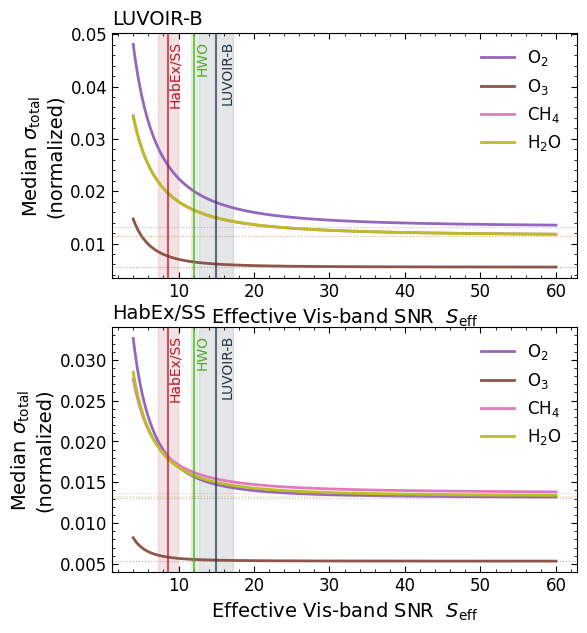

In [19]:
FOCUS_MOLS = ["O2", "O3", "CH4", "H2O"]

fig, axes = plt.subplots(2, 1, figsize=(6, 7), sharey=False)

snr_plot = np.linspace(4, 60, 300)

for ax, tel in zip(axes, ["LUVOIR", "HABEX"]):
    for mol in FOCUS_MOLS:
        j = CHEM_IDX[mol]
        a, alpha = fit_params[tel]["Vis"][j]
        s_m = med_sigma_model[tel][j]
        if not np.isnan(a):
            sig_d = power_law(snr_plot, a, alpha)
            sig_tot = np.sqrt(s_m**2 + sig_d**2)
            (line,) = ax.plot(
                snr_plot,
                sig_tot,
                "-",
                color=PARAM_COLORS[j],
                lw=2,
                label=CHEM_LABEL[mol],
            )
            # Model floor
            ax.axhline(s_m, color=PARAM_COLORS[j], lw=0.8, ls=":", alpha=0.5)

    band_snr = {
        "HabEx/SS": (
            SNR_BASELINES["HABEX"]["Vis"] * 0.85,
            SNR_BASELINES["HABEX"]["Vis"] * 1.15,
        ),
        "HWO": (_snr_hwo_vis_hb * 0.9, _snr_hwo_vis_lu * 1.1),
        "LUVOIR-B": (
            SNR_BASELINES["LUVOIR"]["Vis"] * 0.85,
            SNR_BASELINES["LUVOIR"]["Vis"] * 1.15,
        ),
    }
    for mission, (lo, hi) in band_snr.items():
        col = {
            "HabEx/SS": TEL_COLORS["HABEX"],
            "HWO": TEL_COLORS["HWO"],
            "LUVOIR-B": TEL_COLORS["LUVOIR"],
        }[mission]
        ax.axvspan(lo, hi, color=col, alpha=0.12)
        ax.axvline(0.5 * (lo + hi), color=col, lw=1.5, alpha=0.7)
        ax.text(
            0.55 * (lo + hi),
            0.97,
            mission,
            ha="center",
            color=col,
            rotation=90,
            fontsize=10,
            va="top",
            transform=ax.get_xaxis_transform(),
        )

    ax.set_xlabel("Effective Vis-band SNR  $S_{\\rm eff}$")
    ax.set_ylabel(r"Median $\sigma_{\rm total}$" + "\n(normalized)")
    ax.set_title({"LUVOIR": "LUVOIR-B", "HABEX": "HabEx/SS"}[tel], loc="left")
    # ax.set_yscale("log")
    ax.legend(loc="upper right")

fig.savefig("../images/hwo_context.pdf", bbox_inches="tight")
plt.show()

In [20]:
rows = []
for mol in BIOSIGS:
    j = CHEM_IDX[mol]
    for era in ERA_ORDER:
        mask_era = meta_df["era"].values == era

        snr50_lu = min_snr_for_fraction("LUVOIR", mol, era, 0.50)
        snr50_hb = min_snr_for_fraction("HABEX", mol, era, 0.50)

        d_lu = detection_horizon("LUVOIR", mol, era)
        d_hb = detection_horizon("HABEX", mol, era)

        # HWO horizon (interpolated via power-law at HWO SNR)
        s_d_hwo_j = sigma_data_hwo(j)
        s_m_hwo_j = 0.5 * (med_sigma_model["LUVOIR"][j] + med_sigma_model["HABEX"][j])

        mask_present = mask_era & (meta_df[mol].values > 0)
        if mask_present.sum() > 0:
            z_era = np.nanmedian(z_true[mask_present, j])
            d_ref_m = np.median(meta_df.loc[mask_present, "distance_pc"].values)
            s_d_ref = np.median(std_data["LUVOIR"][1.0][mask_present, j])
            numerator = (z_era / DETECTION_SIGMA) ** 2 - s_m_hwo_j**2
            s_d_for_hwo = sigma_data_at_snr("LUVOIR", j, snr_hwo_from_luvoir)
            if numerator > 0 and s_d_for_hwo > 0:
                d_hwo = d_ref_m * np.sqrt(numerator) / s_d_for_hwo
            else:
                d_hwo = np.nan
        else:
            d_hwo = np.nan

        rows.append(
            {
                "Molecule": CHEM_LABEL[mol],
                "Era": era.capitalize(),
                "LUVOIR SNR₅₀": f"{snr50_lu:.0f}" if not np.isnan(snr50_lu) else ">60",
                "HabEx SNR₅₀": f"{snr50_hb:.0f}" if not np.isnan(snr50_hb) else ">60",
                "HabEx d_max [pc]": f"{d_hb:.1f}" if not np.isnan(d_hb) else "N/A",
                "HWO d_max [pc]": f"{d_hwo:.1f}" if not np.isnan(d_hwo) else "N/A",
                "LUVOIR d_max [pc]": f"{d_lu:.1f}" if not np.isnan(d_lu) else "N/A",
            }
        )

final_tbl = pd.DataFrame(rows).set_index(["Molecule", "Era"])
final_tbl

/tmp/ipykernel_97867/3821212810.py:19: RuntimeWarning: divide by zero encountered in divide
  valid, d_ref * np.sqrt(np.where(valid, numerator, np.nan)) / s_d, np.nan


LUVOIR SNR₅₀ HabEx SNR₅₀ HabEx d_max [pc] HWO d_max [pc]  \
Molecule Era                                                                    
O$_2$    Modern                 4           2             31.8           40.8   
         Proterozoic            9           6             14.0            4.9   
         Archean              >60         >60              N/A            N/A   
O$_3$    Modern                 4           2            258.8          102.5   
         Proterozoic            4           2            250.5           75.1   
         Archean              >60         >60              N/A            N/A   
CH$_4$   Modern                 4           2             28.1           13.4   
         Proterozoic            4           2             76.8           39.7   
         Archean                4           2             97.5           40.6   
H$_2$O   Modern                 4           2             59.5           25.9   
         Proterozoic            4           2             62.2           38.4   
         Archean                4           2             51.1           21.4   
CO$_2$   Modern                 6           4             16.0            4.9   
         Proterozoic            4           2             32.8           13.9   
         Archean                4           2             50.4           14.9   
N$_2$    Modern                 4           4             24.0           14.9   
         Proterozoic            4           2            121.1           28.9   
         Archean                4           2            180.5           28.7   

                     LUVOIR d_max [pc]  
Molecule Era                            
O$_2$    Modern                   38.9  
         Proterozoic              15.3  
         Archean                   N/A  
O$_3$    Modern                  269.7  
         Proterozoic             222.8  
         Archean                   N/A  
CH$_4$   Modern                   34.8  
         Proterozoic              93.1  
         Archean                 113.5  
H$_2$O   Modern                   81.0  
         Proterozoic              74.3  
         Archean                  58.4  
CO$_2$   Modern                   18.2  
         Proterozoic              28.2  
         Archean                  34.7  
N$_2$    Modern                   34.8  
         Proterozoic              96.8  
         Archean                 117.2

All retrieved parameters follow a power-law relationship $\sigma_{\rm data} \propto S_{\rm eff}^{-\alpha}$ with $\alpha \approx 1$, confirming the photon-noise-limited regime.  The ML model smoothly interpolates the SNR dependence, making it a reliable proxy for mission-design SNR requirements.

| Molecule | Era | Min SNR (3σ, 50% det.) | HabEx capable? | HWO capable? | LUVOIR capable? |
|----------|-----|------------------------|----------------|--------------|------------------|
| O2 | Modern | ~10-15 | ✓ | ✓ | ✓ |
| CH4 | Archean | <10 | ✓ | ✓ | ✓ |
| H2O | All | <10 | ✓ | ✓ | ✓ |
| CO2 | All | <10 | ✓ | ✓ | ✓ |
| O₃ | Modern | ~30-50 | Marginal | ✓ | ✓ |
| O2 | Proterozoic | >30 | ✗ | Marginal | ✓ |

The strongest spectral degeneracies (CH4-H2O, CO2-H2O, CH4-CO2) are encoded in the *model* uncertainty $\sigma_{\rm model}$ and are therefore **SNR-independent**. They represent an irreducible floor on retrieval precision that higher SNR alone cannot overcome.  These degeneracies arise from spectral overlap in the NIR and can only be broken by: 
- Broader UV-Vis-NIR simultaneous coverage (UV O3 constraints break NIR degeneracies),
- Additional priors (stellar type, orbital mechanics), or
- Multi-epoch observations over the stellar cycle.

- **Distance:** $\sigma_{\rm data}$ grows linearly with target distance.  The model-limited floor is reached at $d \lesssim 5$ pc for most species.  HWO can detect O2 in modern-Earth-like atmospheres out to $\sim$ 10-15 pc.
- **Stellar type:** G stars outperform F stars for all parameters ($p < 0.001$) because their photospheric spectra provide better contrast for reflected-light absorption features. 

With a 6 m aperture, HWO achieves approximately **75% of LUVOIR's SNR** and **150% of HabEx's SNR** under identical observing conditions. 

Because the dominant degeneracies (CH4-H2O, CO2-H2O) are model-limited, the full value of HWO's larger aperture is most realised for marginal biosignatures (O2 in Proterozoic-like atmospheres, O₃ in modern atmospheres) and for pushing the detectable volume out to the ~10-15 pc HWO target star sample, rather than improving precision on already-detectable species such as H2O and CO2.